In [1]:
from astroquery.sdss import SDSS
from astroquery.ipac.irsa import Irsa
from astroquery.vizier import Vizier
from astropy import coordinates as coord
from astropy import units as u
from astroquery.ipac.ned import Ned
import numpy as np
import pandas as pd

import re
import os
import numpy as np
from astropy.io import ascii
from astropy.io import fits
from astropy.table import Table
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
from matplotlib.ticker import AutoMinorLocator
from astropy.constants import L_sun
from matplotlib import gridspec
import astropy.units as u
from math import pi
import gc
from matplotlib.ticker import ScalarFormatter
import subprocess
from astropy.coordinates import Angle, SkyCoord

In [2]:
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import matplotlib.image as mpimg

In [3]:
storage_dir = os.path.join(os.path.expanduser("~"),'Data_storageHII/')
os.makedirs(storage_dir, exist_ok=True)

img_dir = storage_dir + '/HIIG_img/'

sdssIMGspec_dir = os.path.join(img_dir,'SDSS_specIMG/')
os.makedirs(sdssIMGspec_dir, exist_ok=True)

In [6]:
def magAB_to_flux(mag, mag_err):
    f = 10**(-0.4 * (mag - 8.90))
    ferr = f * np.log(10)/2.5 * mag_err
    return f, ferr

WISE_ZP = {
    'W1': 309.540,
    'W2': 171.787,
    'W3': 31.674,
    'W4': 8.363
}

def vega_to_jy(mag, mag_err, band):
    """Convierte magnitudes Vega de WISE a flux (Jy) con error."""
    f0 = WISE_ZP[band.upper()]
    f = f0 * 10**(-0.4 * mag)
    ferr = f * np.log(10)/2.5 * mag_err
    return f, ferr


def GALEX_data(table,filter_band):
    
    TABLE = table[(table['Observed Passband']==filter_band)]

    check = np.unique(TABLE['Significance'])

    # OJO con esto despues, hay un valor malo aqui es el "SBS 0926+606A" para el FUV
    if ((np.where(check == 'no uncertainty reported'))!= 0)  and (len(np.unique(TABLE['Uncertainty']))==1):
        #CHOSEN = table[table['Significance']=='no uncertainty reported']
        flx = TABLE['Photometry Measurement'][0]

        fx_mJy, fxerr_mJy = magAB_to_flux(flx, 0.0)

        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        fxerr_mJy = np.random.uniform(low=0,high=0.018)
        return fx_mJy * 1e3 , fxerr_mJy * 1e3
    
    else:
        TABLE = table[(table['Observed Passband']==filter_band) & (table['Qualifiers']=='Kron flux in elliptical aperture')]
        errors = np.array(TABLE['Uncertainty'])

        Err_min = np.min(errors)

        CHOSEN = TABLE[TABLE['Uncertainty']==Err_min]


        flx = CHOSEN['Photometry Measurement'][0]
        flx_err = float(CHOSEN['Uncertainty'][0].replace("+/-",""))

        fx_mJy, fxerr_mJy = magAB_to_flux(flx, flx_err)

        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        return fx_mJy * 1e3 , fxerr_mJy * 1e3



def SDSS_data(table,filter_band):
    TABLE = table[(table['Observed Passband']==filter_band)]

    Ref = np.array(TABLE['Refcode'])

    Older_ref = np.max(Ref)

    CHOSEN = TABLE[TABLE['Refcode']==Older_ref]


    flx = CHOSEN['Photometry Measurement'][0]
    flx_err = float(CHOSEN['Uncertainty'][0].replace("+/-",""))

    fx_mJy, fxerr_mJy = magAB_to_flux(flx, flx_err)

    #return flx, flx_err
    #return fx_mJy, fxerr_mJy
    return fx_mJy * 1e3 , fxerr_mJy * 1e3


def WISE_data(table,filter_band):

    band = filter_band[0:2]

    TABLE = table[(table['Observed Passband']==filter_band) & (table['Qualifiers']=='Profile-fit')]

    CHOSEN = TABLE


    flx = CHOSEN['Photometry Measurement'][0]

    str_removal = CHOSEN['Uncertainty'][0].replace("+/-","")
    str_removal = str_removal.replace(">","")

    flx_err = float(str_removal)
    #flx_err = float(CHOSEN['Uncertainty'][0].replace(">",""))

    if ('-' in str(flx)) or ('-' in str(flx_err)):
        return np.nan , np.nan
    else:
        fx_mJy, fxerr_mJy = vega_to_jy(flx, flx_err,band)
        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        return fx_mJy * 1e3 , fxerr_mJy * 1e3

In [7]:
DF = pd.read_csv('/home/holman/HIIGalaxies/Spectral_synthesis/HIIGsample_data.csv')

head = "# id redshift galex.FUV galex.FUV_err galex.NUV galex.NUV_err sloan.sdss.u sloan.sdss.u_err sloan.sdss.g sloan.sdss.g_err sloan.sdss.r sloan.sdss.r_err sloan.sdss.i sloan.sdss.i_err sloan.sdss.z sloan.sdss.z_err wise.W1 wise.W1_err wise.W2 wise.W2_err wise.W3 wise.W3_err wise.W4 wise.W4_err \n"

with open("cigale_HIIG_sample.txt", 'w') as file:
    file.write(head)


    for n in range(len(DF)):

        name = DF['Ned_name'][n]

        filters = ['FUV (GALEX) AB', 'NUV (GALEX) AB','u (SDSS Model) AB','g (SDSS Model) AB','r (SDSS Model) AB','i (SDSS Model) AB','z (SDSS Model) AB',
                  'W1 (WISE)','W2 (WISE)','W3 (WISE)','W4 (WISE)']
        NED_table = Ned.get_table(name, table='photometry')
        ned_filters = np.unique(NED_table['Observed Passband'])

        idx,z = '',0
        fuv,nuv,u,g,r,i,z,W1,W2,W3,W4 = 0,0,0,0,0,0,0,0,0,0,0
        e1,e2,e3,e4,e5,e6,e7,e8,e9,e10,e11 = 0,0,0,0,0,0,0,0,0,0,0

        cond = (filters[0] in ned_filters) and (filters[1] in ned_filters) and (filters[2] in ned_filters) and (filters[3] in ned_filters) and (filters[4] in ned_filters) \
            and (filters[5] in ned_filters) and (filters[6] in ned_filters) and (filters[7] in ned_filters) and (filters[8] in ned_filters) and (filters[9] in ned_filters)

        cond = True

        if cond:
            idx = str(DF['N'][n]) + '_' + str(DF['Name'][n]).replace(' ','')
            z = DF['Z'][n]
            print(idx)

            fuv,e1 = GALEX_data(NED_table,filters[0])
            nuv,e2 = GALEX_data(NED_table,filters[1])

            u,e3 = SDSS_data(NED_table,filters[2])
            g,e4 = SDSS_data(NED_table,filters[3])
            r,e5 = SDSS_data(NED_table,filters[4])
            i,e6 = SDSS_data(NED_table,filters[5])
            z,e7 = SDSS_data(NED_table,filters[6])

            W1,e8 = WISE_data(NED_table,filters[7])
            W2,e9 = WISE_data(NED_table,filters[8])
            W3,e10 = WISE_data(NED_table,filters[9])
            W4,e11 = WISE_data(NED_table,filters[10])



            output = f"{idx} {z} {fuv} {e1} {nuv} {e2} "
            output = output + f"{u} {e3} {g} {e4} {r} {e5} {i} {e6} {z} {e7} "
            output = output + f"{W1} {e8} {W2} {e9} {W3} {e10} {W4} {e11} \n"

            file.write(output)
            


ReadTimeout: HTTPSConnectionPool(host='ned.ipac.caltech.edu', port=443): Read timed out. (read timeout=60)

In [4]:
import cv2
import numpy as np

subprocess.run(['bash', f'relocate_SDSSpublicimgspectra.sh'], capture_output=True, text=True)

CompletedProcess(args=['bash', 'relocate_SDSSpublicimgspectra.sh'], returncode=0, stdout='/home/holman/Data_storageHII/HIIG_img\nProceso finalizado.\n', stderr="mv: cannot stat 'specimage_*': No such file or directory\n")

In [27]:
img_list = os.listdir(img_dir)
img_list.remove('SDSS_specIMG')
img_list = sorted(img_list)
len(img_list)


121

In [42]:

catalog_file = os.path.join(storage_dir,"gal_info_dr7_v5_2.fit.gz")
catalog_fits = fits.open(catalog_file)
catalog=Table.read(catalog_fits[1])
w=((catalog['RA']!=catalog['DEC']) & (catalog['RA']>0) & ((catalog['DEC']>=-90) | (catalog['DEC']<=90)) & (catalog['Z']>=0) & ( catalog['Z'] != float('nan') ) & ( catalog['DEC'] != float('nan') ) & ( catalog['RA'] != float('nan') ))
reduced_cat=catalog[w]
catalog_fits.close()

In [56]:
def coordinate_search(spec_name,table):
    spec_name = spec_name.replace('.fit.jpeg','')
    mjd,plate,fiber = int(spec_name[7:12]),int(spec_name[13:17]),int(spec_name[18:21])
    #print(plate,mjd,fiber)

    result = SDSS.query_specobj(plate=plate,mjd=mjd,fiberID=fiber)

    status = str(type(result)) 

    if (status != "<class 'NoneType'>"):
        ra,dec = result['ra'][0],result['dec'][0]
    else:
        ra = np.array(table[(table['PLATEID']==plate) & (table['FIBERID']==fiber) & (table['MJD']==mjd)]['RA'])[0]
        dec = np.array(table[(table['PLATEID']==plate) & (table['FIBERID']==fiber) & (table['MJD']==mjd)]['DEC'])[0]
        
    return [ra,dec]


centroids = [coordinate_search(x,reduced_cat) for x in img_list] 

In [197]:
Sel = img_list.index('spSpec-53297-1781-055.fit.jpeg')
centroids[Sel]

[124.406602111505, 52.043424036998]

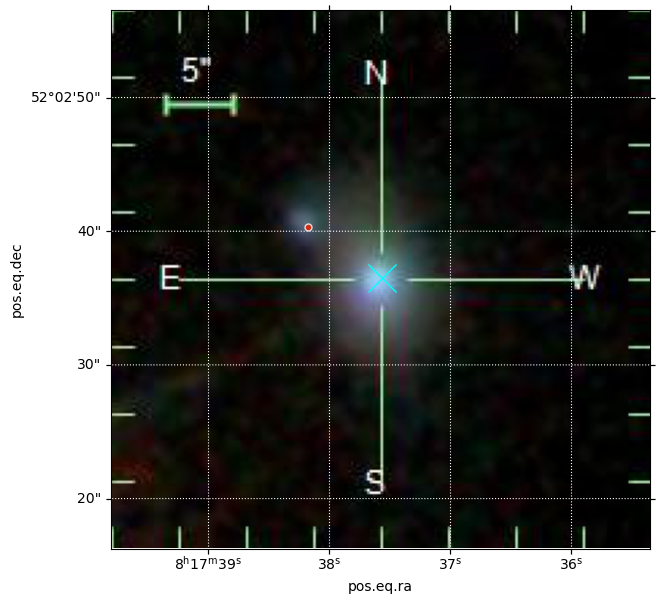

In [199]:
# 1. Load the PNG
img = mpimg.imread(img_dir + img_list[Sel])

img = np.flipud(img)

# 2. Define WCS information (example for 1000x1000 image)
wcs_dict = {
    'CTYPE1': 'RA---SIN', 'CTYPE2': 'DEC--SIN',
    'CRVAL1': centroids[Sel][0], 'CRVAL2': centroids[Sel][1], # RA/Dec of reference pixel
    'CRPIX1': 100., 'CRPIX2': 100.,       # Reference pixel
    'CDELT1': -0.000057, 'CDELT2': 0.000056,  # Pixel scale
    'CUNIT1': 'deg', 'CUNIT2': 'deg',
    'RADESYS': 'ICRS',
    'LONPOLE' : 180.0,'LATPOLE' : 12.9915,
    'MJDREFI' :0.0,'MJDREFF' :0.0,
}
wcs = WCS(wcs_dict)

# 3. Plotting
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(1, 1, 1, projection=wcs)
ax.imshow(img,origin='lower')
ax.grid(color='white', ls=':')


s_x = []
s_y = []
coord_p = SkyCoord(124.409045,52.0445318, unit=(u.deg, u.deg), frame='icrs')
x, y = coord_p.to_pixel(wcs, origin=0)
s_x.append(x)
s_y.append(y)

ax.plot(s_x, s_y,
        markerfacecolor="#ee2400c6", marker='o', markersize=5, linewidth = 0, markeredgewidth = 1,markeredgecolor='white',
        label='spec coords',alpha= 0.8)

ax.plot(wcs_dict['CRPIX1'], wcs_dict['CRPIX2'], 'x', color='cyan', markersize=20)

plt.show()




In [184]:
# Coordenadas de ejemplo
ra, dec = 126.844057066824, 20.436890586719 # en grados
pos = coord.SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')

# ---- 1. SDSS (u,g,r,i,z) ----
sdss_data = SDSS.query_region(
    pos,
    radius=0.01 * u.arcsec,   # <--- este es el argumento que faltaba
    spectro=False,
    photoobj_fields=[
        'ra','dec',
        'modelMag_u','modelMagErr_u',
        'modelMag_g','modelMagErr_g',
        'modelMag_r','modelMagErr_r',
        'modelMag_i','modelMagErr_i',
        'modelMag_z','modelMagErr_z'
    ]
)

sdss_data

objID,ra,dec,modelMag_u,modelMagErr_u,modelMag_g,modelMagErr_g,modelMag_r,modelMagErr_r,modelMag_i,modelMagErr_i,modelMag_z,modelMagErr_z
uint64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1237673807583641672,126.844057066824,20.436890586719,18.69108,0.01883951,18.22884,0.00672459,18.13127,0.007748538,17.72411,0.007762555,18.00035,0.02526004
1237673807583641671,126.844057496516,20.4368901313846,18.63239,0.01858295,18.17727,0.006635874,18.06957,0.007641071,17.66421,0.007704429,17.91238,0.02477617


In [191]:
# Coordenadas de ejemplo
ra, dec = 126.844057066824, 20.436890586719 # en grados
pos = coord.SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')

# ---- 4. WISE (W1–W4) ----
wise = Irsa.query_region(pos, 
                         catalog='allwise_p3as_psd', 
                         spatial='Cone', 
                         radius=0.9*u.arcsec)
wise['w1mpro','w1sigmpro','w2mpro','w2sigmpro','w3mpro','w3sigmpro','w4mpro','w4sigmpro']
wise


designation,ra,dec,sigra,sigdec,sigradec,glon,glat,elon,elat,wx,wy,cntr,source_id,coadd_id,src,w1mpro,w1sigmpro,w1snr,w1rchi2,w2mpro,w2sigmpro,w2snr,w2rchi2,w3mpro,w3sigmpro,w3snr,w3rchi2,w4mpro,w4sigmpro,w4snr,w4rchi2,rchi2,nb,na,w1sat,w2sat,w3sat,w4sat,satnum,ra_pm,dec_pm,sigra_pm,sigdec_pm,sigradec_pm,pmra,sigpmra,pmdec,sigpmdec,w1rchi2_pm,w2rchi2_pm,w3rchi2_pm,w4rchi2_pm,rchi2_pm,pmcode,cc_flags,rel,ext_flg,var_flg,ph_qual,det_bit,moon_lev,w1nm,w1m,w2nm,w2m,w3nm,w3m,w4nm,w4m,w1cov,w2cov,w3cov,w4cov,w1cc_map,w1cc_map_str,w2cc_map,w2cc_map_str,w3cc_map,w3cc_map_str,w4cc_map,w4cc_map_str,best_use_cntr,ngrp,w1flux,w1sigflux,w1sky,w1sigsk,w1conf,w2flux,w2sigflux,w2sky,w2sigsk,w2conf,w3flux,w3sigflux,w3sky,w3sigsk,w3conf,w4flux,w4sigflux,w4sky,w4sigsk,w4conf,w1mag,w1sigm,w1flg,w1mcor,w2mag,w2sigm,w2flg,w2mcor,w3mag,w3sigm,w3flg,w3mcor,w4mag,w4sigm,w4flg,w4mcor,w1mag_1,w1sigm_1,w1flg_1,w2mag_1,w2sigm_1,w2flg_1,w3mag_1,w3sigm_1,w3flg_1,w4mag_1,w4sigm_1,w4flg_1,w1mag_2,w1sigm_2,w1flg_2,w2mag_2,w2sigm_2,w2flg_2,w3mag_2,w3sigm_2,w3flg_2,w4mag_2,w4sigm_2,w4flg_2,w1mag_3,w1sigm_3,w1flg_3,w2mag_3,w2sigm_3,w2flg_3,w3mag_3,w3sigm_3,w3flg_3,w4mag_3,w4sigm_3,w4flg_3,w1mag_4,w1sigm_4,w1flg_4,w2mag_4,w2sigm_4,w2flg_4,w3mag_4,w3sigm_4,w3flg_4,w4mag_4,w4sigm_4,w4flg_4,w1mag_5,w1sigm_5,w1flg_5,w2mag_5,w2sigm_5,w2flg_5,w3mag_5,w3sigm_5,w3flg_5,w4mag_5,w4sigm_5,w4flg_5,w1mag_6,w1sigm_6,w1flg_6,w2mag_6,w2sigm_6,w2flg_6,w3mag_6,w3sigm_6,w3flg_6,w4mag_6,w4sigm_6,w4flg_6,w1mag_7,w1sigm_7,w1flg_7,w2mag_7,w2sigm_7,w2flg_7,w3mag_7,w3sigm_7,w3flg_7,w4mag_7,w4sigm_7,w4flg_7,w1mag_8,w1sigm_8,w1flg_8,w2mag_8,w2sigm_8,w2flg_8,w3mag_8,w3sigm_8,w3flg_8,w4mag_8,w4sigm_8,w4flg_8,w1magp,w1sigp1,w1sigp2,w1k,w1ndf,w1mlq,w1mjdmin,w1mjdmax,w1mjdmean,w2magp,w2sigp1,w2sigp2,w2k,w2ndf,w2mlq,w2mjdmin,w2mjdmax,w2mjdmean,w3magp,w3sigp1,w3sigp2,w3k,w3ndf,w3mlq,w3mjdmin,w3mjdmax,w3mjdmean,w4magp,w4sigp1,w4sigp2,w4k,w4ndf,w4mlq,w4mjdmin,w4mjdmax,w4mjdmean,rho12,rho23,rho34,q12,q23,q34,xscprox,w1rsemi,w1ba,w1pa,w1gmag,w1gerr,w1gflg,w2rsemi,w2ba,w2pa,w2gmag,w2gerr,w2gflg,w3rsemi,w3ba,w3pa,w3gmag,w3gerr,w3gflg,w4rsemi,w4ba,w4pa,w4gmag,w4gerr,w4gflg,tmass_key,r_2mass,pa_2mass,n_2mass,j_m_2mass,j_msig_2mass,h_m_2mass,h_msig_2mass,k_m_2mass,k_msig_2mass,x,y,z,spt_ind,htm20
,deg,deg,arcsec,arcsec,arcsec,deg,deg,deg,deg,pix,pix,,,,,mag,mag,,,mag,mag,,,mag,mag,,,mag,mag,,,,,,,,,,,deg,deg,arcsec,arcsec,arcsec,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,count,mag,mag,,mag,mag,mag,,mag,mag,mag,,mag,mag,mag,,mag,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,mag,,,,,,,mag,mag,mag,,,,,,,mag,mag,mag,,,,,,,mag,mag,mag,,,,,,,,,,,,,arcsec,arcsec,,deg,mag,mag,,arcsec,,deg,mag,mag,,arcsec,,deg,mag,mag,,arcsec,,deg,mag,mag,,,arcsec,deg,,mag,mag,mag,mag,mag,mag,,,,,
object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,object,object,int64,float32,float32,float64,float32,float32,float32,float64,float32,float32,float32,float64,float32,float32,float32,float64,float32,float32,int64,int64,float32,float32,float32,float32,object,float64,float64,float64,float64,float64,int64,int64,int64,int64,float32,float32,float32,float32,float32,object,object,object,int64,object,object,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,int64,object,int64,object,int64,object,int64,object,int64,int32,float32,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,int64,float32,float32,float32,int64,float32,float32,float32,int64,float32,float3

In [187]:
result_table = Ned.get_table("WISEA J082722.53+202613.0", table='photometry')


#result_table[result_table['Observed Passband']=='FUV (GALEX) AB']
result_table

No.,Observed Passband,Photometry Measurement,Uncertainty,Units,Frequency,Flux Density,Upper limit of uncertainty,Lower limit of uncertainty,Upper limit of Flux Density,Lower limit of Flux Density,NED Uncertainty,NED Units,Refcode,Significance,Published frequency,Frequency Mode,Coordinates Targeted,Spatial Mode,Qualifiers,Comments
,,,,,Hz,Jy,,,,,,,,,,,,,,
int32,object,float64,object,object,float64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object,object,object,object
1,FUV (GALEX) AB,19.1539,+/-0.158269,mag,1950000000000000.0,7.92e-05,1.15e-05,1.15e-05,--,--,+/-1.15E-05,Jy,2012GASC..C...0000S,uncertainty,1538.6 A,Broad-band measurement,126.84397130536 20.437010461977 (J2000),Flux integrated from map,Kron flux in elliptical aperture,From new raw data
2,FUV (GALEX) AB,19.7865,+/-0.228998,mag,1950000000000000.0,4.42e-05,9.32e-06,9.32e-06,--,--,+/-9.32E-06,Jy,2012GASC..C...0000S,uncertainty,1538.6 A,Broad-band measurement,126.84397130536 20.437010461977 (J2000),Flux in fixed aperture,Flux in 7.5 arcsec diameter aperture,From new raw data
3,NUV (GALEX) AB,18.6609,+/-0.0716256,mag,1290000000000000.0,0.000125,8.22e-06,8.22e-06,--,--,+/-8.22E-06,Jy,2012GASC..C...0000S,uncertainty,2315.7 A,Broad-band measurement,126.84397130536 20.437010461977 (J2000),Flux integrated from map,Kron flux in elliptical aperture,From new raw data
4,NUV (GALEX) AB,19.2788,+/-0.0992250,mag,1290000000000000.0,7.06e-05,6.45e-06,6.45e-06,--,--,+/-6.45E-06,Jy,2012GASC..C...0000S,uncertainty,2315.7 A,Broad-band measurement,126.84397130536 20.437010461977 (J2000),Flux in fixed aperture,Flux in 7.5 arcsec diameter aperture,From new raw data
5,u (SDSS Model) AB,18.684,+/-0.022,asinh mag,836000000000000.0,0.000127,2.57e-06,2.57e-06,--,--,+/-2.57E-06,Jy,2006SDSS5.C...0000:,based on count statistics only,3585 A,Broad-band measurement,126.844070 20.436876 (J2000),Modelled datum,SDSS flags: CHILD - object is part of a blended parent object; BAD_RADIAL - some low S/N radial points; PETROFAINT - Petrosian radius measured at very low surface brightness; BINNED1 - detected at >=5 sigma in original imaging frame; BINNED_CENTER - image was binned while centroiding; BRIGHTEST_GALAXY_CHILD - brightest child among one parent's children;,From new raw data
6,u (SDSS CModel) AB,18.737,,asinh mag,836000000000000.0,0.000121,--,--,--,--,,Jy,2006SDSS5.C...0000:,no uncertainty reported,3585 A,Broad-band measurement,126.844070 20.436876 (J2000),Modelled datum,SDSS flags: CHILD - object is part of a blended parent object; BAD_RADIAL - some low S/N radial points; PETROFAINT - Petrosian radius measured at very low surface brightness; BINNED1 - detected at >=5 sigma in original imaging frame; BINNED_CENTER - image was binned while centroiding; BRIGHTEST_GALAXY_CHILD - brightest child among one parent's children;,From new raw data
7,u (SDSS Petrosian)AB,18.765,+/-0.031,asinh mag,836000000000000.0,0.000117,3.35e-06,3.35e-06,--,--,+/-3.35E-06,Jy,2006SDSS5.C...0000:,based on count statistics only,3585 A,Broad-band measurement,126.844070 20.436876 (J2000),Modelled datum,"SDSS Petrosian Radius = 0.60"". \nSDSS flags: CHILD - object is part of a blended parent object; BAD_RADIAL - some low S/N radial points; PETROFAINT - Petrosian radius measured at very low surface brightness; BINNED1 - detected at >=5 sigma in original imaging frame; BINNED_CENTER - image was binned while centroiding; BRIGHTEST_GALAXY_CHILD - brightest child among one parent's children;",From new raw data
8,u (SDSS PSF) AB,18.933,+/-0.026,asinh mag,836000000000000.0,0.000101,2.41e-06,2.41e-06,--,--,+/-2.41E-06,Jy,2007SDSS6.C...0000:,based on count statistics only,3585 A,Broad-band measurement,126.8440695807 20.4368767136 (J2000),Modelled datum,SDSS flags: CHILD - object is part of a blended parent object; BAD_RADIAL - some low S/N radial points; PETROFAINT - Petrosian radius measured at very low surface brightness; BINNED1 - detected at >=5 sigma in original imaging frame; BINNED_CENTER - imag

In [188]:
np.unique(result_table['Observed Passband'])

FUV (GALEX) AB
H (2MASS/FLWO)
H{beta}
J (2MASS/FLWO)
K_s (2MASS/FLWO)
NUV (GALEX) AB
W1 (WISE)
W2 (WISE)
W3 (WISE)
W4 (WISE)
g (SDSS CModel) AB


In [ ]:
import os
HOME = os.path.expanduser("~") + '/gdrive/DataHII/'

def magAB_to_flux(mag, mag_err):
    f = 10**(-0.4 * (mag - 8.90))
    ferr = f * np.log(10)/2.5 * mag_err
    return f, ferr

WISE_ZP = {
    'W1': 309.540,
    'W2': 171.787,
    'W3': 31.674,
    'W4': 8.363
}

def vega_to_jy(mag, mag_err, band):
    """Convierte magnitudes Vega de WISE a flux (Jy) con error."""
    f0 = WISE_ZP[band.upper()]
    f = f0 * 10**(-0.4 * mag)
    ferr = f * np.log(10)/2.5 * mag_err
    return f, ferr



def GALEX_data(table,filter_band):
    
    TABLE = table[(table['Observed Passband']==filter_band)]

    check = np.unique(TABLE['Significance'])

    # OJO con esto despues, hay un valor malo aqui es el "SBS 0926+606A" para el FUV
    if ((np.where(check == 'no uncertainty reported'))!= 0)  and (len(np.unique(TABLE['Uncertainty']))==1):
        #CHOSEN = table[table['Significance']=='no uncertainty reported']
        flx = TABLE['Photometry Measurement'][0]

        fx_mJy, fxerr_mJy = magAB_to_flux(flx, 0.0)

        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        fxerr_mJy = np.random.uniform(low=0,high=0.018)
        return fx_mJy * 1e3 , fxerr_mJy * 1e3
    
    else:
        TABLE = table[(table['Observed Passband']==filter_band) & (table['Qualifiers']=='Kron flux in elliptical aperture')]
        errors = np.array(TABLE['Uncertainty'])

        Err_min = np.min(errors)

        CHOSEN = TABLE[TABLE['Uncertainty']==Err_min]


        flx = CHOSEN['Photometry Measurement'][0]
        flx_err = float(CHOSEN['Uncertainty'][0].replace("+/-",""))

        fx_mJy, fxerr_mJy = magAB_to_flux(flx, flx_err)

        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        return fx_mJy * 1e3 , fxerr_mJy * 1e3



def SDSS_data(table,filter_band):
    TABLE = table[(table['Observed Passband']==filter_band)]

    Ref = np.array(TABLE['Refcode'])

    Older_ref = np.max(Ref)

    CHOSEN = TABLE[TABLE['Refcode']==Older_ref]


    flx = CHOSEN['Photometry Measurement'][0]
    flx_err = float(CHOSEN['Uncertainty'][0].replace("+/-",""))

    fx_mJy, fxerr_mJy = magAB_to_flux(flx, flx_err)

    #return flx, flx_err
    #return fx_mJy, fxerr_mJy
    return fx_mJy * 1e3 , fxerr_mJy * 1e3










def WISE_data(table,filter_band):

    band = filter_band[0:2]

    TABLE = table[(table['Observed Passband']==filter_band) & (table['Qualifiers']=='Profile-fit')]

    CHOSEN = TABLE


    flx = CHOSEN['Photometry Measurement'][0]

    str_removal = CHOSEN['Uncertainty'][0].replace("+/-","")
    str_removal = str_removal.replace(">","")

    flx_err = float(str_removal)
    #flx_err = float(CHOSEN['Uncertainty'][0].replace(">",""))

    if ('-' in str(flx)) or ('-' in str(flx_err)):
        return np.nan , np.nan
    else:
        fx_mJy, fxerr_mJy = vega_to_jy(flx, flx_err,band)
        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        return fx_mJy * 1e3 , fxerr_mJy * 1e3

In [7]:
# Sacando los datos para CIGALE

DF = pd.read_csv(HOME+'/SPS/HIIGs_aladin.csv')

head = "# id redshift galex.FUV galex.FUV_err galex.NUV galex.NUV_err "
head = head + "sloan.sdss.u sloan.sdss.u_err sloan.sdss.g sloan.sdss.g_err sloan.sdss.r sloan.sdss.r_err sloan.sdss.i sloan.sdss.i_err sloan.sdss.z sloan.sdss.z_err "
head = head + "wise.W1 wise.W1_err wise.W2 wise.W2_err wise.W3 wise.W3_err wise.W4 wise.W4_err \n"

with open("cigale_HIIG_sample.txt", 'w') as file:
    file.write(head)


    for n in range(len(DF)):

        name = DF['Name'][n]

        filters = ['FUV (GALEX) AB', 'NUV (GALEX) AB','u (SDSS Model) AB','g (SDSS Model) AB','r (SDSS Model) AB','i (SDSS Model) AB','z (SDSS Model) AB',
                  'W1 (WISE)','W2 (WISE)','W3 (WISE)','W4 (WISE)']
        NED_table = Ned.get_table(name, table='photometry')
        ned_filters = np.unique(NED_table['Observed Passband'])

        idx,z = '',0
        fuv,nuv,u,g,r,i,z,W1,W2,W3,W4 = 0,0,0,0,0,0,0,0,0,0,0
        e1,e2,e3,e4,e5,e6,e7,e8,e9,e10,e11 = 0,0,0,0,0,0,0,0,0,0,0

        cond = (filters[0] in ned_filters) and (filters[1] in ned_filters) and (filters[2] in ned_filters) and (filters[3] in ned_filters) and (filters[4] in ned_filters) \
            and (filters[5] in ned_filters) and (filters[6] in ned_filters) and (filters[7] in ned_filters) and (filters[8] in ned_filters) and (filters[9] in ned_filters)

        
        if cond:
            idx = str(DF['N'][n]) + '_' + str(DF['Name'][n]).replace(' ','')
            z = DF['Z'][n]
            print(idx)

            fuv,e1 = GALEX_data(NED_table,filters[0])
            nuv,e2 = GALEX_data(NED_table,filters[1])

            u,e3 = SDSS_data(NED_table,filters[2])
            g,e4 = SDSS_data(NED_table,filters[3])
            r,e5 = SDSS_data(NED_table,filters[4])
            i,e6 = SDSS_data(NED_table,filters[5])
            z,e7 = SDSS_data(NED_table,filters[6])

            W1,e8 = WISE_data(NED_table,filters[7])
            W2,e9 = WISE_data(NED_table,filters[8])
            W3,e10 = WISE_data(NED_table,filters[9])
            W4,e11 = WISE_data(NED_table,filters[10])



            output = f"{idx} {z} {fuv} {e1} {nuv} {e2} "
            output = output + f"{u} {e3} {g} {e4} {r} {e5} {i} {e6} {z} {e7} "
            output = output + f"{W1} {e8} {W2} {e9} {W3} {e10} {W4} {e11} \n"

            file.write(output)
            




0_UM199
1_UM282
2_UM336
4_SBS0934+546
5_UM570
6_UM162
10_SHOC391
11_WAS69
12_WAS17
14_WISEAJ095227.57+322810.3
15_WISEAJ094252.78+354725.7
16_WISEAJ105040.86+342946.3
17_TOLOLO1057+083
20_SHOC143
21_SHOC220
22_SHOC316
23_SHOC008
24_SBS0813+521
25_WISEAJ094809.88+425713.1
28_SHOC022
29_WISEAJ121329.48+114057.2
31_WISEAJ130119.26+123959.7
32_WISEAJ104653.98+134646.4
33_SHOC293
34_SBS0926+606A
36_SHOC282
38_SHOC014
39_SHOC043
40_SHOC113
41_SHOC592
42_SHOC590
43_SHOC247
44_WISEAJ231442.11+010621.6
46_SHOC084
47_SHOC115
48_SHOC133
51_SHOC153
52_SHOC174
53_SHOC203
57_SHOC486
58_SHOC584
59_SHOC586
60_SHOC595
62_WISEAJ104457.84+035312.9
63_WISEAJ105326.00+043014.5
65_WISEAJ220802.85+131334.5
66_WISEAJ212043.94+010006.9
67_WISEAJ104755.92+073951.2
68_WISEAJ214350.85-072003.9
69_WISEAJ092540.91+063116.8
71_WISEAJ092749.17+084037.1
72_WISEAJ101036.62+641242.6
73_WISEAJ100746.48+025229.1
74_WISEAJ222510.11-001153.1
76_WISEAJ105210.40+032712.7
78_WISEAJ102429.21+052451.0
79_WISEAJ090531.04+033530.3

In [8]:
#Numero de galaxias con datos completos

DF = pd.read_csv(HOME+'/SPS/HIIGs_aladin.csv')

HIIG_names = np.array(DF['Name'])

print('Name | FUV | NUV | u | g | r | i | z | W1 | W2 | W3 | W4 | ALL |')

sep = ' | '

name_id = 0

Found = 0

for name in HIIG_names:
    result_table = Ned.get_table(name, table='photometry')
    filters = np.unique(result_table['Observed Passband'])

    c = 0 

    tab = str(name_id) + '_id' + sep

    #FUV
    if 'FUV (GALEX) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #NUV
    if 'NUV (GALEX) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #u
    if 'u (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #g
    if 'g (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #r
    if 'r (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #i
    if 'i (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #z
    if 'z (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W1
    if 'W1 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W2
    if 'W2 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W3
    if 'W3 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W4
    if 'W4 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    


    if c == 11:
        tab += '  All found' + sep
        Found += 1
        print(tab + name)
    else:
        tab += str(0) + sep


    

    name_id += 1

print(f'\n Found complete:{Found}')    
    


Name | FUV | NUV | u | g | r | i | z | W1 | W2 | W3 | W4 | ALL |
0_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | UM 199
1_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | UM 282
2_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | UM 336
4_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | SBS 0934+546
5_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | UM 570
6_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | UM 162
10_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | SHOC 391
11_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | WAS 69
12_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | WAS 17
14_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | WISEA J095227.57+322810.3
15_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | WISEA J094252.78+354725.7
16_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | WISEA J105040.86+342946.3


In [9]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
Vizier.clear_cache()

In [25]:
DF

,N,Name,ra,dec,Z,PLATE,MJD,FIBERID
0,0,UM 199,1.737614,0.857181,0.073682,388,51793,457
1,1,UM 282,12.947112,0.161124,0.037556,394,51913,472
2,2,UM 336,23.436174,0.953078,0.019236,400,51820,441
3,3,MRK 0627,131.643397,36.438978,0.010634,934,52672,369
4,4,SBS 0934+546,144.556301,54.473618,0.102102,556,51991,224
...,...,...,...,...,...,...,...,...
116,116,WISEA J103226.97+271755.3,158.112320,27.298679,0.192490,2353,53794,585
117,117,WISEA J101136.07+263027.5,152.900317,26.507660,0.054666,2347,53757,501
118,118,WISEA J162152.58+151855.9,245.469098,15.315537,0.034341,2208,53880,306
119,119,WISEA J090506.84+223834.7,136.278600,22.642759,0.125548,2284,53708,545


In [42]:
Vizier.ROW_LIMIT = 10000 
for i in range(len(DF)):
    ra, dec = DF['ra'][i], DF['dec'][i]
    pos = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")

    cat_id = "II/319/las9"

    res = Vizier.query_region(pos, radius=1*u.arcsec, catalog=cat_id)

    if res:
        tab = res[0]
        df = tab.to_pandas()
        LEN = len(df)
    else:
        print("Sin detección en UKIDSS dentro del radio dado  ",i)






    


Sin detección en UKIDSS dentro del radio dado   3
Sin detección en UKIDSS dentro del radio dado   4
Sin detección en UKIDSS dentro del radio dado   7
Sin detección en UKIDSS dentro del radio dado   8
Sin detección en UKIDSS dentro del radio dado   9
Sin detección en UKIDSS dentro del radio dado   12
Sin detección en UKIDSS dentro del radio dado   13
Sin detección en UKIDSS dentro del radio dado   14
Sin detección en UKIDSS dentro del radio dado   15
Sin detección en UKIDSS dentro del radio dado   16
Sin detección en UKIDSS dentro del radio dado   19
Sin detección en UKIDSS dentro del radio dado   21
Sin detección en UKIDSS dentro del radio dado   22
Sin detección en UKIDSS dentro del radio dado   23
Sin detección en UKIDSS dentro del radio dado   24
Sin detección en UKIDSS dentro del radio dado   25
Sin detección en UKIDSS dentro del radio dado   26
Sin detección en UKIDSS dentro del radio dado   34
Sin detección en UKIDSS dentro del radio dado   38
Sin detección en UKIDSS dentro del r

In [35]:
# Configuración
Vizier.ROW_LIMIT = 10000  # puedes aumentar si buscas muchos objetos
#Vizier.columns = ["RAJ2000", "DEJ2000", "Ymag", "Jmag", "Hmag", "Kmag", "e_Ymag", "e_Jmag", "e_Hmag", "e_Kmag"]

# Coordenadas del objeto
ra, dec = 12.947112,0.16112404 # grados
pos = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")

# Catálogo UKIDSS LAS en VizieR
cat_id = "II/319/"  # DR9 LAS (hay DR10/DR11 también)

# Consulta por radio
res = Vizier.query_region(pos, radius=1*u.arcsec, catalog=cat_id)

if res:
    tab = res[0]
    df = tab.to_pandas()
    df
else:
    print("Sin detección en UKIDSS dentro del radio dado.")


df

,ULAS,m,RAJ2000,DEJ2000,Ymag,e_Ymag,Jmag1,e_Jmag1,Jmag2,e_Jmag2,Hmag,e_Hmag,Kmag,e_Kmag,Epoch,pmRA,pmDE,cl
0,J005147.32+000939.9,1,12.947188,0.161089,18.503,0.043,18.181,0.064,NaN,NaN,17.636999,0.057,17.327,0.094,2005.7657,NaN,NaN,1


In [11]:
from astroquery.vizier import Vizier
vizier = Vizier() # this instantiates Vizier with its default parameters
catalog_list = vizier.find_catalogs('ukidss')

for k, v in catalog_list.items():
    print(k, ":", v.description)

II/316 : UKIDSS-DR6 Galactic Plane Survey (Lucas+ 2012)
II/319 : UKIDSS-DR9 LAS, GCS and DXS Surveys (Lawrence+ 2012)


In [12]:
from astroquery.vizier import Vizier
vizier = Vizier() # this instantiates Vizier with its default parameters
catalog_list = vizier.find_catalogs('wise')

for k, v in catalog_list.items():
    print(k, ":", v.description)

II/311 : WISE All-Sky Data Release (Cutri+ 2012)
II/328 : AllWISE Data Release (Cutri+ 2013)
II/363 : The band-merged unWISE Catalog (Schlafly+, 2019)
II/365 : The CatWISE2020 catalog (updated version 28-Jan-2021) (Marocco+, 2021)


In [14]:
vizier.ROW_LIMIT = 50
UKIDSS = vizier.get_catalogs("II/319/las9")
Uk_cat = UKIDSS[0]
Uk_cat = Uk_cat.to_pandas()
Uk_cat

,ULAS,m,RAJ2000,DEJ2000,Ymag,e_Ymag,Jmag1,e_Jmag1,Jmag2,e_Jmag2,Hmag,e_Hmag,Kmag,e_Kmag,Epoch,pmRA,pmDE,cl
0,J131601.51-001710.5,1,199.006326,-0.286277,NaN,NaN,18.550,0.095,NaN,NaN,17.636000,0.100,16.819000,0.080,2005.4480,NaN,NaN,1
1,J131606.65-001737.0,1,199.027721,-0.293624,NaN,NaN,NaN,NaN,NaN,NaN,18.854000,0.194,18.184000,0.181,2009.1556,NaN,NaN,-2
2,J131607.02-001721.4,2,199.029261,-0.289282,18.007000,0.024,NaN,NaN,NaN,NaN,16.862000,0.032,16.669001,0.046,2009.4343,NaN,NaN,-1
3,J131607.02-001721.4,1,199.029267,-0.289279,NaN,NaN,17.429,0.035,NaN,NaN,16.959000,0.054,16.806000,0.080,2005.4480,NaN,NaN,-1
4,J131605.36-001725.9,1,199.022372,-0.290555,NaN,NaN,NaN,NaN,NaN,NaN,18.785000,0.182,18.122000,0.171,2009.1556,NaN,NaN,-1
5,J131605.36-001725.8,2,199.022367,-0.290509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.117001,0.265,2005.3768,NaN,NaN,-1
6,J131610.62-001658.7,1,199.044253,-0.282975,NaN,NaN,18.749,0.114,NaN,NaN,NaN,NaN,17.797001,0.198,2005.4480,NaN,NaN,-2
7,J131610.63-001658.6,2,199.044322,-0.282950,19.334000,0.074,NaN,NaN,NaN,NaN,18.393000,0.127,NaN,NaN,2009.4343,NaN,NaN,1
8,J131611.00-001656.6,2,199.045860,-0.282390,19.186001,0.065,NaN,NaN,NaN,NaN,18.112000,0.098,18.047001,0.159,2009.4343,NaN,NaN,-1
9,J131611.00-001656.5,1,199.045855,-0.282371,NaN,NaN,18.631,0.103,NaN,NaN,18.118999,0.156,17.756001,0.191,2005.4480,NaN,NaN,-1


In [15]:
Vizier(catalog="II/319").get_catalog_metadata()

title,authors,abstract,origin_article,webpage,created,updated,waveband,doi
object,object,object,object,object,object,object,object,object
"UKIDSS-DR9 LAS, GCS and DXS Surveys","Lawrence A.; Warren S.J.; Almaini O.; Edge A.C.; Hambly N.C.; Jameson R.F.,Lucas P.; Casali M.; Adamson A.; Dye S.; Emerson J.P.; Foucaud S.,Hewett P.; Hirst P.; Hodgkin S.T.; Irwin M.J.; Lodieu N.; McMahon R.G.,Simpson C.; Smail I.; Mortlock D.; Folger M.","The UKIRT Infrared Deep Sky Survey (UKIDSS) is a large-scale near-IR survey which aim is to cover 7500 square degrees of the Northern sky. The survey is carried out using the Wide Field Camera (WFCAM), with a field of view of 0.21 square degrees, mounted on the 3.8m United Kingdom Infra-red Telescope (UKIRT) in Hawaii. The project comprises five surveys (LAS, GCS, DXS, GPS and UDS). The Large Area Survey (LAS) covers an area of 4000 square degrees in high Galactic latitudes (extragalactic) in the four bands Y(1.0um) J(1.2um) H(1.6um) and K(2.2um) to a depth of K=18.4. This release 9 includes proper motions for a fraction (~1/6) of the sources. The Galactic Clusters Survey (GCS) aims to survey ten large open star clusters and star formation associations, covering a total of 1067 square degrees in the five bands Z (0.9um), Y(1.0um) J(1.2um) H(1.6um) and K(2.2um), plus a second pass in K for proper motions, to a depth of Z=20.4, Y=20.3, J=19.5, H=18.6, K=18.6. This release 9 includes proper motions for a fraction (~1/4) of the sources. The Deep Extragalactic Survey (DXS) aims to map 35 square degrees of sky to a 5-{sigma} point-source sensitivity of J=22.3 and K=20.8 in four carefully selected, multi-wavelength survey areas. The central regions of each field will also be mapped to H=21.8. The primary aim of the survey is to produce a photometric galaxy sample at a redshift of 1-2, within a volume comparable to that of the SDSS, selected in the same passband (rest frame optical). Details of the surveys can be found in the in the paper by Lawrence et al. (2007MNRAS.379.1599L), and at the UKIDSS Surveys site (http://www.ukidss.org/surveys/surveys.html). The data described here represent a subset of the UKIDSS data, limited to the public data and most representative columns. In the ""Byte-by-byte Description"" below the original names of the columns are given as bracketed names. Usage of the UKIDSS data: All users of UKIDSS data should include an acknowledgement in their publications as follows: ""This work is based in part on data obtained as part of the UKIRT Infrared Deep Sky Survey"".",2007MNRAS.379.1599L,https://cdsarc.cds.unistra.fr/viz-bin/cat/II/319,2013-04-16T12:29:07,2025-06-13T15:25:00,infrared,--


In [5]:
from astroquery.ukidss import Ukidss
import astropy.coordinates as coord
import astropy.units as u


DF = pd.read_csv('/home/holman/HIIGalaxies/Spectral_synthesis/HIIGsample_data.csv')


table = Ukidss.query_region(coord.SkyCoord(126.844057066824, 20.436890586719,
                                           unit=(u.deg, u.deg),
                                           frame="icrs"),
                            programme_id="LAS", radius=100 * u.arcsec)
table


for i in range(len(DF)):
    ra, dec = DF['RA'][i], DF['DEC'][i]
    table = Ukidss.query_region(coord.SkyCoord(ra,dec,
                                           unit=(u.deg, u.deg),
                                           frame="icrs"),
                            programme_id="LAS", radius=1 * u.arcsec)
    if len(table)!=0:
        print("Found: ", i)




KeyboardInterrupt: 

Filename: 65_WISEAJ220802.85+131334.5_SFH.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     69   300R x 2C   [K, D]   


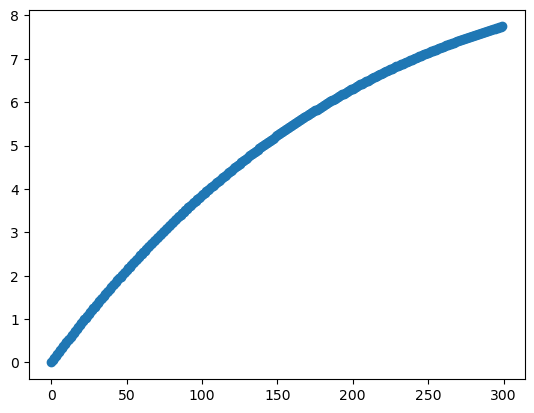

In [12]:
CIGALE_output = fits.open('65_WISEAJ220802.85+131334.5_SFH.fits')

CIGALE_output.info()
SFH = Table.read(CIGALE_output[1])
SFH

plt.plot(SFH['time'],SFH['SFR'],marker='o')

In [13]:
SFH

time,SFR
Myr,solMass / yr
int64,float64
0,0.0
1,0.04700572014994827
2,0.0938236053168914
3,0.140454218442649
4,0.18689812096936248
5,0.23315587284324094
6,0.2792280325182972
7,0.3251151569600757


In [35]:
CIGALE_output[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   16 / length of dimension 1                          
NAXIS2  =                  300 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    2 / number of table fields                         
TTYPE1  = 'time    '                                                            
TFORM1  = 'K       '                                                            
TUNIT1  = 'Myr     '                                                            
TTYPE2  = 'SFR     '                                                            
TFORM2  = 'D       '        

In [6]:
CIGALE_output = fits.open('65_WISEAJ220802.85+131334.5_best_model.fits')

CIGALE_output.info()

DATA = Table.read(CIGALE_output[1])
DATA

Filename: 65_WISEAJ220802.85+131334.5_best_model.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    111   4291R x 16C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   


wavelength,Fnu,L_lambda_total,stellar.old,stellar.young,nebular.absorption_old,nebular.absorption_young,nebular.emission_old,nebular.emission_young,attenuation.stellar.old,attenuation.stellar.young,attenuation.nebular.emission_old,attenuation.nebular.emission_young,dust.Umin_Umin,dust.Umin_Umax,igm
nm,mJy,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
10.30626129325507,0.0,0.0,2.127194157391114e+31,1.5371425097180099e+32,-2.127194157391114e+31,-1.5371425097180099e+32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
10.646028149076667,1.6141908409121697e-22,2.119839945935125e+16,2.44467405617532e+31,1.7513519021806686e+32,-2.44467405617532e+31,-1.7513519021806686e+32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-7291114713942.388
10.872539386291065,0.0,0.0,2.58300353816064e+31,1.8726840537410333e+32,-2.58300353816064e+31,-1.8726840537410333e+32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
11.09905062350546,0.0,0.0,8.48570105951758e+31,1.0885713457495637e+33,-8.48570105951758e+31,-1.0885713457495637e+33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
11.325561860719857,0.0,0.0,2.100434028099311e+32,3.029400849936519e+33,-2.100434028099311e+32,-3.029400849936519e+33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
11.552073097934256,0.0,0.0,2.2507311930986716e+32,3.2891250113578456e+33,-2.2507311930986716e+32,-3.2891250113578456e+33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
11.778584335148652,0.0,0.0,2.1666942388450753e+32,3.1207975739603984e+33,-2.1666942388450753e+32,-3.1207975739603984e+33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
12.00509557236305,0.0,0.0,2.2033537634093362e+32,3.1722056633893756e+33,-2.2033537634093362e+32,-3.1722056633893756e+33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0


/tmp/ipykernel_983056/355304291.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['L_lambda_total']),label = 'L')
/tmp/ipykernel_983056/355304291.py:3: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['L_lambda_total']),label = 'L')
/tmp/ipykernel_983056/355304291.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['stellar.young']), label= 'Old')
/tmp/ipykernel_983056/355304291.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['stellar.old']),label = 'Young')
/tmp/ipykernel_983056/355304291.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['nebular.emission_old']), label = 'Nebular Emission')
/tmp/ipykernel_983056/355304291.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.p

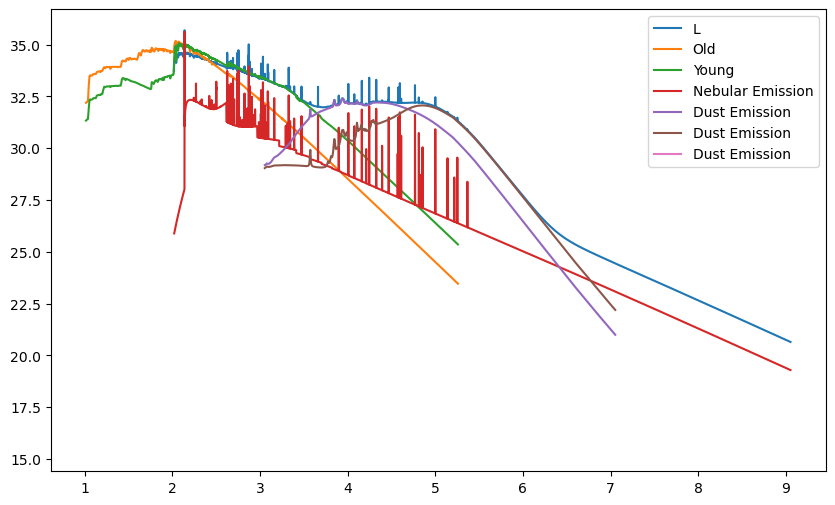

In [11]:
plt.figure(figsize=(10,6))

plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['L_lambda_total']),label = 'L')
plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['stellar.young']), label= 'Old')
plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['stellar.old']),label = 'Young')
plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['nebular.emission_old']), label = 'Nebular Emission')
plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['dust.Umin_Umax']), label = 'Dust Emission')
plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['dust.Umin_Umin']), label = 'Dust Emission')
plt.plot(np.log10(DATA['wavelength']),np.log10(DATA['igm']), label = 'Dust Emission')



plt.legend()

In [15]:
CIGALE_output[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  128 / length of dimension 1                          
NAXIS2  =                 4291 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   16 / number of table fields                         
TTYPE1  = 'wavelength'                                                          
TFORM1  = 'D       '                                                            
TUNIT1  = 'nm      '                                                            
TTYPE2  = 'Fnu     '                                                            
TFORM2  = 'D       '        

In [2]:
CIGALE_output = fits.open('65_WISEAJ220802.85+131334.5_chi2-block-0.fits')

CIGALE_output.info()

Filename: 65_WISEAJ220802.85+131334.5_chi2-block-0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     10   1382400R x 1C   [D]   


In [3]:
CIGALE_output[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                    8 / length of dimension 1                          
NAXIS2  =              1382400 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    1 / number of table fields                         
TTYPE1  = 'chi2    '                                                            
TFORM1  = 'D       '                                                            

In [4]:
DATA = Table.read(CIGALE_output[1])
DATA

chi2
float64
456.40501142549806
456.40501142549806
456.40501142549806
456.40501142549806
456.40501142549806
456.40501142549806
456.40501142549806
456.40501142549806
456.40501142549806
